CONFIDENCE INTERVALS & BOOTSTRAP

📊 culmen_length_mm
  n = 344
  Mean = 43.925
  95% CI: (43.350, 44.500)
  Using z (normal) distribution

📊 culmen_depth_mm
  n = 344
  Mean = 17.152
  95% CI: (16.944, 17.360)
  Using z (normal) distribution

📊 flipper_length_mm
  n = 344
  Mean = 200.892
  95% CI: (199.410, 202.374)
  Using z (normal) distribution

📊 body_mass_g
  n = 344
  Mean = 4200.872
  95% CI: (4116.365, 4285.379)
  Using z (normal) distribution

📊 culmen_area_mm2
  n = 344
  Mean = 750.891
  95% CI: (738.729, 763.054)
  Using z (normal) distribution

📊 flipper_to_mass_ratio
  n = 344
  Mean = 0.049
  95% CI: (0.048, 0.050)
  Using z (normal) distribution

📊 culmen_length_mm (Bootstrap)
  Original mean: 43.925
  Bootstrap mean: 43.923
  95% Bootstrap CI: (43.348, 44.500)

📊 culmen_depth_mm (Bootstrap)
  Original mean: 17.152
  Bootstrap mean: 17.152
  95% Bootstrap CI: (16.943, 17.358)

📊 flipper_length_mm (Bootstrap)
  Original mean: 200.892
  Bootstrap mean: 200.896
  95% Boot

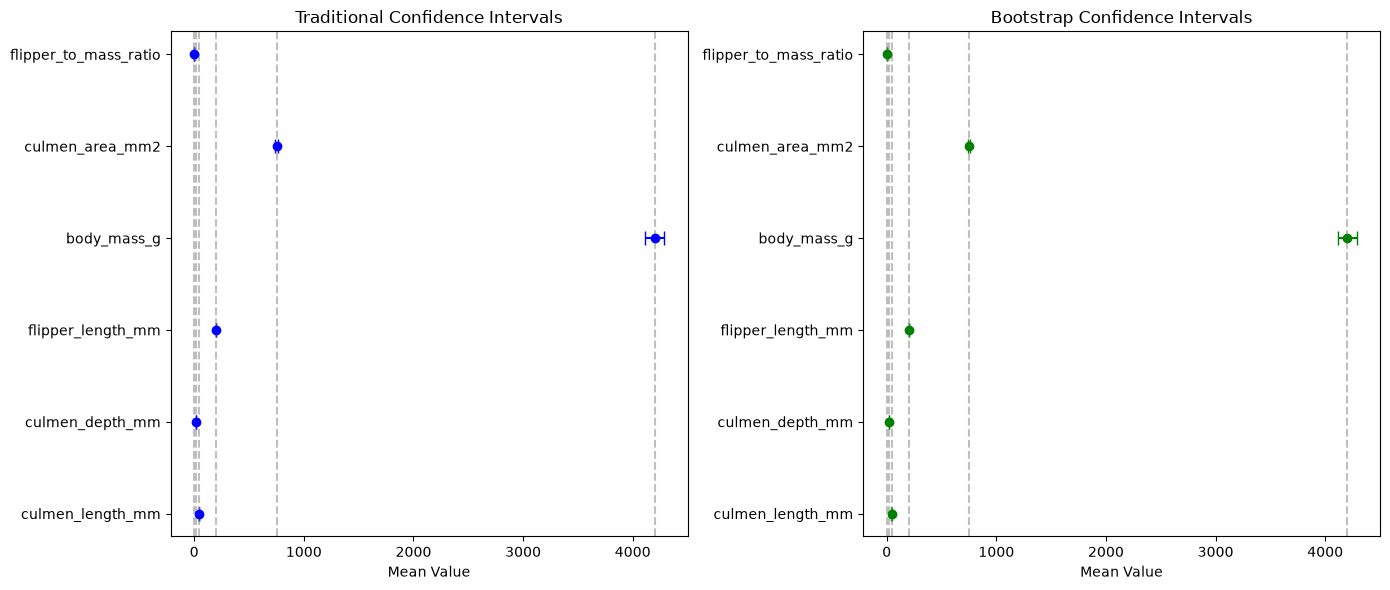


 Confidence interval visualizations saved


In [3]:
import sys
sys.path.append('..')

import pandas as pd 

import numpy as np 

from src.data_loader import DataLoader 

from src.statistics import StatisticalAnalyzer 
from scipy import stats
import matplotlib.pyplot as plt 

import seaborn as sns 

 

# Load cleaned data 

loader = DataLoader(data_dir="../data") 

df = pd.read_csv(loader.processed_dir / "cleaned_data.csv") 

 

print("=" * 60) 
print("CONFIDENCE INTERVALS & BOOTSTRAP") 
print("=" * 60) 

import os                                    



# ==================== 1. CONFIDENCE INTERVALS ==================== 

 

def calculate_confidence_interval(data, confidence=0.95): 

    """Calculate confidence interval for mean.""" 

    n = len(data) 

    mean = np.mean(data) 

    std = np.std(data, ddof=1) 

    se = std / np.sqrt(n) 

     

    if n >= 30: 

        z_score = stats.norm.ppf((1 + confidence) / 2) 

        margin = z_score * se 

        dist = 'z (normal)' 

    else: 

        t_score = stats.t.ppf((1 + confidence) / 2, df=n-1) 

        margin = t_score * se 

        dist = 't (Student\'s)' 

     

    return { 

        'n': n, 

        'mean': mean, 

        'std': std, 

        'se': se, 

        'margin': margin, 

        'lower': mean - margin, 

        'upper': mean + margin, 

        'distribution': dist 

    } 

 



numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns 

ci_results = {} 

 

for col in numeric_cols: 

    data = df[col].dropna() 

    if len(data) > 0: 

        ci_results[col] = calculate_confidence_interval(data) 

         

        print(f"\n📊 {col}") 

        print(f"  n = {ci_results[col]['n']}") 

        print(f"  Mean = {ci_results[col]['mean']:.3f}") 

        print(f"  95% CI: ({ci_results[col]['lower']:.3f}, {ci_results[col]['upper']:.3f})") 

        print(f"  Using {ci_results[col]['distribution']} distribution") 

 

# ==================== 2. BOOTSTRAP ==================== 

 

def bootstrap_ci(data, statistic=np.mean, n_bootstrap=10000, confidence=0.95): 

    """Calculate bootstrap confidence interval.""" 

    n = len(data) 

    bootstrap_stats = [] 

     

    for _ in range(n_bootstrap): 

        sample = np.random.choice(data, size=n, replace=True) 

        bootstrap_stats.append(statistic(sample)) 

     

    alpha = 1 - confidence 

    lower = np.percentile(bootstrap_stats, alpha/2 * 100) 

    upper = np.percentile(bootstrap_stats, (1 - alpha/2) * 100) 

     

    return { 

        'original': statistic(data), 

        'bootstrap_mean': np.mean(bootstrap_stats), 

        'bootstrap_std': np.std(bootstrap_stats), 

        'lower': lower, 

        'upper': upper, 

        'confidence': confidence 

    } 

 

# Bootstrap for each numeric column 

bootstrap_results = {} 

 

for col in numeric_cols: 

    data = df[col].dropna() 

    if len(data) > 0: 

        bootstrap_results[col] = bootstrap_ci(data) 

         

        print(f"\n📊 {col} (Bootstrap)") 

        print(f"  Original mean: {bootstrap_results[col]['original']:.3f}") 

        print(f"  Bootstrap mean: {bootstrap_results[col]['bootstrap_mean']:.3f}") 

        print(f"  95% Bootstrap CI: ({bootstrap_results[col]['lower']:.3f}, {bootstrap_results[col]['upper']:.3f})") 

 

# ==================== 3. COMPARE CI METHODS ==================== 

 

print("\n" + "=" * 60) 

print("COMPARISON: Traditional CI vs Bootstrap CI") 

print("=" * 60) 

 

comparison_data = [] 

for col in numeric_cols: 

    if col in ci_results and col in bootstrap_results: 

        comparison_data.append({ 

            'column': col, 

            'mean': ci_results[col]['mean'], 

            'ci_lower': ci_results[col]['lower'], 

            'ci_upper': ci_results[col]['upper'], 

            'bootstrap_lower': bootstrap_results[col]['lower'], 

            'bootstrap_upper': bootstrap_results[col]['upper'], 

            'ci_width': ci_results[col]['upper'] - ci_results[col]['lower'], 

            'bootstrap_width': bootstrap_results[col]['upper'] - bootstrap_results[col]['lower'] 

        }) 

 

comparison_df = pd.DataFrame(comparison_data) 

comparison_df.to_csv('../reports/ci_comparison.csv', index=False) 

 

print("\n Confidence interval results saved to '../reports/ci_comparison.csv'") 

 

# ================= 4. VISUALIZE CONFIDENCE INTERVALS ================= 

 

def plot_confidence_intervals(ci_results, bootstrap_results): 

    """Plot confidence intervals for all numeric columns.""" 

    cols = list(ci_results.keys()) 

     

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6)) 

     

    # Traditional CIs 

    for i, col in enumerate(cols): 

        ci = ci_results[col] 

        ax1.errorbar(ci['mean'], i,  

                    xerr=ci['margin'],  

                    fmt='o', capsize=5, color='blue') 

        ax1.set_yticks(range(len(cols))) 

        ax1.set_yticklabels(cols) 

        ax1.axvline(x=ci['mean'], color='gray', linestyle='--', alpha=0.5) 

        ax1.set_xlabel('Mean Value') 

        ax1.set_title('Traditional Confidence Intervals') 

     

 

    for i, col in enumerate(cols): 

        if col in bootstrap_results: 

            boot = bootstrap_results[col] 

            ax2.errorbar(boot['original'], i,  

                        xerr=[[boot['original'] - boot['lower']],  

                              [boot['upper'] - boot['original']]],  

                        fmt='o', capsize=5, color='green') 

        ax2.set_yticks(range(len(cols))) 

        ax2.set_yticklabels(cols) 

        ax2.axvline(x=boot['original'], color='gray', linestyle='--', alpha=0.5) 

        ax2.set_xlabel('Mean Value') 

        ax2.set_title('Bootstrap Confidence Intervals') 

     

    plt.tight_layout() 

    plt.savefig('../reports/figures/confidence_intervals_comparison.png', dpi=300, bbox_inches='tight') 

    plt.show() 

 



if ci_results and bootstrap_results: 

    plot_confidence_intervals(ci_results, bootstrap_results) 

 

print("\n Confidence interval visualizations saved") 

